In [6]:
# this project is to obtain a matrix table where we can take a look at the specific currencies intended. 
# for a start lets try to do a 10 x 10 matrix for the G10 currencies. 
# for columns it will be the BUY leg
# for the rows it will be SELL leg. 
# g10 currencies are as follows:
# 1. USD
# 2. EUR
# 3. JPY 
# 4. GBP
# 5. AUD
# 6. NZD
# 7. CAD
# 8. CHF
# 9. NOK
# 10. SEK
# lets go. 


In [7]:
import numpy as np
import pandas as pd
import os
import yfinance as yf # source data
import re
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

In [8]:
# lets create a simple matrix 
ccy_list = [
    'USD',
    'EUR',
    'JPY',
    'GBP',
    'AUD',
    'NZD',
    'CAD',
    'CHF',
    'NOK',
    'SEK']

# for each column for each row, you need to obtain the necessary buy/sell legs
# if col == row then leave it blank?
ccy_pairs_dict = {}
ccy_pairs_only_dict = {}
for col in ccy_list:
    # print(col)
    medium_list = []
    medium_dict = {}
    for row in ccy_list:
        # print(row)
        if col == row:
            key_ccy_pair = col + row
            val_ccy_pair = 1
        else:
            key_ccy_pair = col + row
            yf_ticker = col + row + "=X"
            val_ccy_pair = 1
            #print(f"key_ccy_pair is: {key_ccy_pair}")
            #fx_rate_df = yf.download(yf_ticker, period = '1mo')['Close']
            #print(f"length of fx_rate_df is: \n {len(fx_rate_df)}")
            #print(f"index fx_rate_df is:\n {fx_rate_df.loc[fx_rate_df.index.max()].values}")
            #val_ccy_pair = fx_rate_df.loc[fx_rate_df.index.max()].values
        medium_dict[key_ccy_pair] = val_ccy_pair
        medium_list.append(key_ccy_pair)
    ccy_pairs_only_dict[col] = medium_list
    ccy_pairs_dict[col] = medium_dict
#ccy_pairs_only_dict
#ccy_pairs_dict

In [9]:
# now that we have the key = columns, values = col/values pair.
# lets see if we can concat the data together. 
# we shall create separate tables for each currencies and then go from there. 

ccy_matrix_df = pd.DataFrame.from_dict(ccy_pairs_only_dict, orient = 'index', columns = ccy_list)
ccy_matrix_df = ccy_matrix_df.T.copy()
#display(ccy_matrix_df)

# take the off diagonals. 
yf_fx_rate_list = []
for i in range(len(ccy_matrix_df)):
    for j in range(len(ccy_matrix_df)):
        if i == j:
            #print(f"ccy is the same: {ccy_matrix_df.iloc[i,j]}.")
            #print(f"we shall skip this ccy pair")
            continue
        else:
            ccy_fx_pair = ccy_matrix_df.iloc[i,j] + "=X"
            yf_fx_rate_list.append(ccy_fx_pair)
#print(yf_fx_rate_list)
#print(len(yf_fx_rate_list))


all_fx_rate_df = yf.download(yf_fx_rate_list, period = '1mo')['Close']
# rearrange the columns to fit the matrix above.. 
all_fx_rate_df = all_fx_rate_df[yf_fx_rate_list]
#print(display(all_fx_rate_df))

# lets get the change between today vs yesterday. 
all_fx_rate_chg_df = all_fx_rate_df.pct_change(1)
#all_fx_rate_chg_df


[*********             19%                       ]  17 of 90 completed$NZDSEK=X: possibly delisted; no price data found  (period=1mo)
[*********************100%***********************]  89 of 90 completed

1 Failed download:
['NZDSEK=X']: possibly delisted; no price data found  (period=1mo)


In [10]:
all_fx_rate_max_df = all_fx_rate_df.copy()
all_fx_rate_max_df = all_fx_rate_max_df.loc[all_fx_rate_max_df.index.max()]

all_fx_rate_chg_max_df = all_fx_rate_chg_df.copy()
all_fx_rate_chg_max_df = all_fx_rate_chg_max_df.loc[all_fx_rate_chg_max_df.index.max()]

clean_tickers_name = [re.sub(r"=X$", "", ticker) for ticker in all_fx_rate_max_df.index.tolist()]
#clean_tickers_name
all_fx_rate_max_df.index = clean_tickers_name
all_fx_rate_chg_max_df.index = clean_tickers_name

#display(all_fx_rate_max_df)
#display(ccy_matrix_df)
# series to dictionary
all_fx_rate_max_dict = all_fx_rate_max_df.to_dict()
all_fx_rate_chg_max_df = all_fx_rate_chg_max_df.to_dict()
all_fx_rate_max_dict

rate_matrix_df = ccy_matrix_df.map(lambda x: all_fx_rate_max_dict.get(x, None)).fillna(0)
rate_change_matrix_df =ccy_matrix_df.map(lambda x: all_fx_rate_chg_max_df.get(x, None)).fillna(0)
#display(rate_matrix_df)
#display(rate_change_matrix_df)

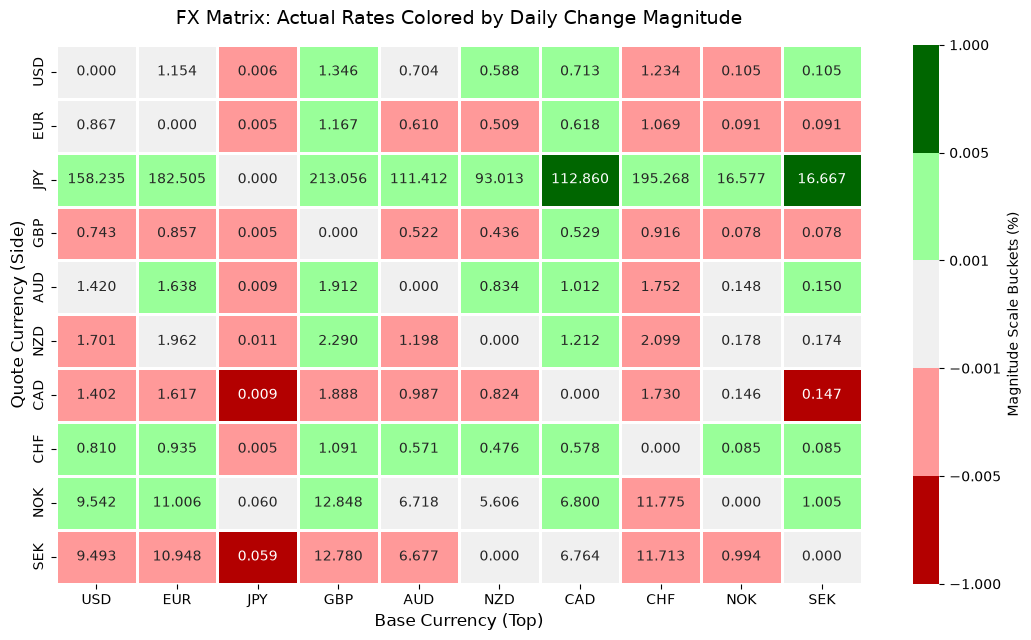

In [11]:
# lets put the heatmap matrix now. 

# 1. rotate the graph. 
heatmap_color_data = rate_change_matrix_df
heatmap_text_data = rate_matrix_df

# 2. create the custom magnitude color buckets
# colors: [Dark Red, Light red, Neutral/White, Light Green, Dark Green]
colors = ['#b30000', '#ff9999', '#f0f0f0', '#99ff99', '#006600']
custom_cmap = mcolors.ListedColormap(colors)

# Define boundaries based on criteria (-0.5%, -0.05%, 0.05%, 0.5%)
bounds = [-1, -0.005, -0.0005, 0.0005, 0.005, 1]
custom_norm = mcolors.BoundaryNorm(bounds, custom_cmap.N)

plt.figure(figsize=(13,7))

# plot the heatmap
sns.heatmap(
    heatmap_color_data,
    annot = heatmap_text_data, # Show the percentage values in the cells. 
    fmt = ".3f",   # Format numbers to 2 decimal places
    cmap = custom_cmap,   # Use custom discrete colors
    norm = custom_norm,   # Enforces the magnitude color rules
    cbar_kws = {'label' : 'Magnitude Scale Buckets (%)'},   
    linewidths = 1.0,   # Add thin lines between cells for readability.
    
)

plt.title("FX Matrix: Actual Rates Colored by Daily Change Magnitude", fontsize = 14, pad = 15)
plt.xlabel("Base Currency (Top)", fontsize = 12)
plt.ylabel("Quote Currency (Side)", fontsize = 12)
plt.show()